# <center>**Phase II: Feature Engineering**

In [1]:
import os
os.getcwd()
os.chdir('E:/DSP')

## **Importing Modules and Libraries**

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.preprocessing import PowerTransformer

import warnings
warnings.filterwarnings('ignore')

## **Loading Data**

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df_train = pd.read_csv('study_materials/LearnML/regression_project/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv('study_materials/LearnML/regression_project/house-prices-advanced-regression-techniques/test.csv')

In [73]:
df_train.head(10)

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500
1,1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500
2,2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500
3,3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000
4,4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000
5,5,6,50,RL,85.0,14115,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,No fireplace,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,No pool,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,6,7,20,RL,75.0,10084,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,No pool,No fence,No extras,0,8,2007,WD,Normal,307000
7,7,8,60,RL,80.0,10382,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,No pool,No fence,Shed,350,11,2009,WD,Normal,200000
8,8,9,50,RM,51.0,6120,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,F

## **Gathering Basic Info**

In [6]:
df_train.shape

(1460, 81)

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
"""
LotFrontage - Interpolate 
Alley - 'No alley access'
MasVnrType - 'None'
MasVnrArea - Interpolate
BsmtQual - 'No basement'
BsmtCond - 'No basement'
BsmtExposure - 'No basement'
BsmtFinType1 - 'No basement'
BsmtFinType2 - 'No basement'
Electrical - Decide
FireplaceQu - Depends on Fireplaces (if 0, then 'No fireplace')
GarageType - 'No garage'
GarageYrBlt - '0'
GarageFinish - 'No garage'
GarageQual - 'No garage'
GarageCond - 'No garage'
PoolQC - Depends on PoolArea (if 0, then 'No pool')
Fence - 'No fence'
MiscFeature - 'No extras'
"""

"\nLotFrontage - Interpolate \nAlley - 'No alley access'\nMasVnrType - 'None'\nMasVnrArea - Interpolate\nBsmtQual - 'No basement'\nBsmtCond - 'No basement'\nBsmtExposure - 'No basement'\nBsmtFinType1 - 'No basement'\nBsmtFinType2 - 'No basement'\nElectrical - Decide\nFireplaceQu - Depends on Fireplaces (if 0, then 'No fireplace')\nGarageType - 'No garage'\nGarageYrBlt - '0'\nGarageFinish - 'No garage'\nGarageQual - 'No garage'\nGarageCond - 'No garage'\nPoolQC - Depends on PoolArea (if 0, then 'No pool')\nFence - 'No fence'\nMiscFeature - 'No extras'\n"

In [9]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
num_cols = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
            'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 
            'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 
            '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 
            'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 
            'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 
            'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
            'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 
            'MiscVal', 'YrSold', 'SalePrice']

In [11]:
cat_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley',
            'LotShape', 'LandContour', 'Utilities', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle','RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
            'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
            'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 
            'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
            'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 
            'MoSold', 'SaleType', 'SaleCondition']

In [12]:
nom_cat_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley',
            'LotShape', 'LandContour', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 
            'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 
            'Heating', 'CentralAir', 'Electrical', 'GarageType', 
            'PavedDrive', 'Fence', 'MiscFeature', 'MoSold', 
            'SaleType', 'SaleCondition']

ord_cat_cols = ['Utilities', 'ExterQual', 'ExterCond', 'BsmtQual', 
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
                'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 
                'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC']

## **Filling Missing Values**

In [13]:
# Replacing null values by the replacements
cat_replacements = {
    'Alley': 'No alley access',
    'MasVnrType': 'None',
    'BsmtQual': 'No basement',
    'BsmtCond': 'No basement',
    'BsmtExposure': 'No basement',
    'BsmtFinType1': 'No basement',
    'BsmtFinType2': 'No basement',
    'GarageType': 'No garage',
    'GarageFinish': 'No garage',
    'GarageQual': 'No garage',
    'GarageCond': 'No garage',
    'Fence': 'No fence',
    'MiscFeature': 'No extras'
}
df_train.fillna(value=cat_replacements, inplace=True)

df_train['GarageYrBlt'].fillna(0, inplace=True)

df_train['LotFrontage'] = df_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
# Fill any remaining gaps (e.g., if a neighborhood has no LotFrontage data) with the overall median
df_train['LotFrontage'] = df_train['LotFrontage'].fillna(df_train['LotFrontage'].median())

df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(df_train['MasVnrArea'].median())

In [14]:
# FireplaceQu: If Fireplaces == 0, fill with 'No fireplace'
df_train.loc[(df_train['FireplaceQu'].isnull()) & (df_train['Fireplaces'] == 0), 'FireplaceQu'] = 'No fireplace'
# Catch-all just in case there are remaining nulls where Fireplaces > 0
df_train['FireplaceQu'].fillna('No fireplace', inplace=True)

# PoolQC: If PoolArea == 0, fill with 'No pool'
df_train.loc[(df_train['PoolQC'].isnull()) & (df_train['PoolArea'] == 0), 'PoolQC'] = 'No pool'
df_train['PoolQC'].fillna('No pool', inplace=True)

# Filling with the mode (most frequent value) of the column
electrical_mode = df_train['Electrical'].mode()[0]
df_train['Electrical'].fillna(electrical_mode, inplace=True)

In [15]:
# Verification
remaining_nulls = df_train[num_cols + cat_cols].isnull().sum()
print("Remaining null values per column:")
print(remaining_nulls[remaining_nulls > 0])

Remaining null values per column:
Series([], dtype: int64)


## **Handling Outliers**

In [16]:
pd.set_option('display.max_rows', None)

In the scatterplot between `GrLivArea` and `SalePrice`, there were two outliers with large area and less price which is unusual to find. It is better to drop those rows so that it doesn't influence the model. 

In [17]:
df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice']<200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,No alley access,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260,Unf,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,Gd,BuiltIn,2007.0,Fin,3,884,TA,TA,Y,208,406,0,0,0,0,No pool,No fence,No extras,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,No alley access,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,No fence,No extras,0,1,2008,New,Partial,160000


In [18]:
df_train = df_train.drop(index=[523, 1298])

Moreover, a specific outlier having more than 6000sqft total basement area is also dropped automatically while dropping the above two rows. Similar to `GrLivArea`, `LotArea` also has same type of outliers which are better to drop.

In [19]:
df_train[(df_train['LotArea'] > 100000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,80.0,159000,Pave,No alley access,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,1Fam,1.5Fin,6,7,1958,2006,Gable,CompShg,Wd Sdng,HdBoard,BrkCmn,472.0,Gd,TA,CBlock,Gd,TA,Gd,Rec,697,Unf,0,747,1444,GasA,Gd,Y,SBrkr,1444,700,0,2144,0,1,2,0,4,1,Gd,7,Typ,2,TA,Attchd,1958.0,Fin,2,389,TA,TA,Y,0,98,0,0,0,0,No pool,No fence,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,No alley access,IR3,Low,AllPub,Inside,Sev,Timber,Norm,Norm,1Fam,1Story,7,5,1965,1965,Hip,CompShg,BrkFace,BrkFace,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,1236,Rec,820,80,2136,GasW,TA,Y,SBrkr,2036,0,0,2036,2,0,2,0,3,1,TA,8,Typ,2,Gd,Attchd,1965.0,RFn,2,513,TA,TA,Y,0,0,0,0,0,0,No pool,No fence,No extras,0,6,2009,WD,Normal,375000
335,336,190,RL,85.0,164660,Grvl,No alley access,IR1,HLS,AllPub,Corner,Sev,Timber,Norm,Norm,2fmCon,1.5Fin,5,6,1965,1965,Gable,CompShg,Plywood,Plywood,None,0.0,TA,TA,CBlock,TA,TA,Gd,ALQ,1249,BLQ,147,103,1499,GasA,Ex,Y,SBrkr,1619,167,0,1786,2,0,2,0,3,1,TA,7,Typ,2,Gd,Attchd,1965.0,Fin,2,529,TA,TA,Y,670,0,0,0,0,0,No pool,No fence,Shed,700,8,2008,WD,Normal,228950
706,707,20,RL,80.0,115149,Pave,No alley access,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,1Fam,1Story,7,5,1971,2002,Gable,CompShg,Plywood,Plywood,Stone,351.0,TA,TA,CBlock,Gd,TA,Gd,GLQ,1219,Unf,0,424,1643,GasA,TA,Y,SBrkr,1824,0,0,1824,1,0,2,0,2,1,Gd,5,Typ,2,TA,Attchd,1971.0,Unf,2,739,TA,TA,Y,380,48,0,0,0,0,No pool,No fence,No extras,0,6,2007,WD,Normal,302000


In [20]:
df_train = df_train.drop(index=[249, 313, 335, 706])

The boxplot of `OverallQual` and `SalePrice` indicated low prices for houses despite having rated 10. Upon inspecting, it is clear that they have vanished while dealing with outliers previously so far.

In [21]:
df_train[(df_train['OverallQual'] == 10) & (df_train['SalePrice'] < 200000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


The single 2-rated house in overall condition seems to be a newly built house (with a garage) sold in the same year which could explain the high price. Thus it is better to keep them in record.

In [22]:
df_train[(df_train['OverallCond'] == 2) & (df_train['SalePrice'] > 200000)].sort_values('SalePrice', ascending=False)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
378,379,20,RL,88.0,11394,Pave,No alley access,Reg,Lvl,AllPub,Corner,Gtl,StoneBr,Norm,Norm,1Fam,1Story,9,2,2010,2010,Hip,CompShg,VinylSd,VinylSd,Stone,350.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1445,Unf,0,411,1856,GasA,Ex,Y,SBrkr,1856,0,0,1856,1,0,1,1,1,1,Ex,8,Typ,1,Ex,Attchd,2010.0,Fin,3,834,TA,TA,Y,113,0,0,0,0,0,No pool,No fence,No extras,0,6,2010,New,Partial,394432


The boxplot for `SaleCondition` vs `SalePrice` revealed an outlier that is very far from the rest of the data points in the `Abnorml` sale condition category. So, it is good to drop them.

In [23]:
df_train[(df_train['SaleCondition'] == 'Abnorml') & (df_train['SalePrice'] > 400000)].sort_values('SalePrice', ascending=False)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,None,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1996.0,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,Ex,MnPrv,No extras,0,7,2007,WD,Abnorml,745000


In [24]:
df_train = df_train.drop(index=1182)

There were a lot of houses rated 5 or 6 with high prices. Before proceeding to drop them, it is better to inspect some other features such as `GrLivArea`, `TotalBsmtSF`, `YearBuilt`, `YrSold`, `SalePrice` to understand why they have been highly priced. 

In [25]:
houses_over_400K_cond56 = df_train[((df_train['OverallCond'] == 5) | (df_train['OverallCond'] == 6)) & (df_train['SalePrice'] > 400000)].sort_values('SalePrice', ascending=False)
houses_over_400K_cond56[['LotArea','Neighborhood','OverallQual',
                         'OverallCond','TotalBsmtSF','GrLivArea',
                         'SaleCondition','YearBuilt','YrSold','SalePrice']]

,LotArea,Neighborhood,OverallQual,OverallCond,TotalBsmtSF,GrLivArea,SaleCondition,YearBuilt,YrSold,SalePrice
691,21535,NoRidge,10,6,2444,4316,Normal,1994,2007,755000
1169,35760,NoRidge,10,5,1930,3627,Normal,1995,2006,625000
898,12919,NridgHt,9,5,2330,2364,Partial,2009,2010,611657
803,13891,NridgHt,9,5,1734,2822,Partial,2008,2009,582933
1046,16056,StoneBr,9,5,1992,2868,Partial,2005,2006,556581
440,15431,NridgHt,10,5,3094,2402,Normal,2008,2009,555000
769,53504,StoneBr,8,5,1650,3279,Normal,2003,2010,538000
178,17423,StoneBr,9,5,2216,2234,Partial,2008,2009,501837
798,13518,NridgHt,9,5,1926,3140,Partial,2008,2009,485000
1373,11400,NoRidge,10,5,2633,2633,Normal,2001,2007,466500


Clearly, most of the houses are new and are sold within an year or two of their creation. With large ground living area and basement, the houses tend to have a higher price rate and it is better not to categorize them as outliers.

Index of rows to be dropped permanently: [249, 313, 335, 706, 523, 1182, 1298]

In [26]:
df_train.reset_index(inplace=True)

In [27]:
df_train.shape

(1453, 82)

In [28]:
df_train.head()

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500
1,1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500
2,2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500
3,3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000
4,4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000


## **Creating New Features**

1. HouseAge = YrSold - YrBuilt
2. OtherRmsAbvGrd = TotRmsAbvGrd - BedroomAbvGrd - KitchenAbvGrd
3. HouseRemod = Y / N (1/0)
4. TotalPorchSF = WoodDeckSF + OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
5. BsmtFinSF2 = Y/N (1/0)
6. LowQualFin = Y/N (1/0)
7. Pool = Y/N (1/0)
8. MiscVal? = Y/N (1/0)

In [29]:
pre_process_df_train = df_train.copy()
pre_process_df_train.drop(columns='index', inplace = True)
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000


In [30]:
# Creating HouseAge variable
pre_process_df_train['HouseAge'] = pre_process_df_train['YrSold'] - pre_process_df_train['YearBuilt']
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500,5
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500,31
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500,7
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000,91
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000,8


In [31]:
# Creating OthRmsAbvGrd variable
pre_process_df_train['OthRmsAbvGrd'] = pre_process_df_train['TotRmsAbvGrd'] - (pre_process_df_train['BedroomAbvGr'] + pre_process_df_train['KitchenAbvGr'])
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,OthRmsAbvGrd
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500,5,4
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500,31,2
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500,7,2
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000,91,3
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000,8,4


In [32]:
# Creating HouseRemod variable
pre_process_df_train['HouseRemod'] = pre_process_df_train.apply(lambda x: 'Y' if x['YearRemodAdd'] > x['YearBuilt'] else 'N', axis=1)
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,OthRmsAbvGrd,HouseRemod
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500,5,4,N
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500,31,2,N
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500,7,2,Y
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000,91,3,Y
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000,8,4,N


In [33]:
# Creating TotalPorchSF variable
pre_process_df_train['TotalPorchSF'] = pre_process_df_train['WoodDeckSF'] + pre_process_df_train['OpenPorchSF'] + pre_process_df_train['EnclosedPorch'] + pre_process_df_train['3SsnPorch'] + pre_process_df_train['ScreenPorch']
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,OthRmsAbvGrd,HouseRemod,TotalPorchSF
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500,5,4,N,61
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500,31,2,N,298
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500,7,2,Y,42
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000,91,3,Y,307
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000,8,4,N,276


In [34]:
# Creating LowQualFin, Pool, MiscVal? variables
pre_process_df_train['LowQualFin'] = pre_process_df_train.apply(lambda x: 'Y' if x['LowQualFinSF'] > 0 else 'N', axis=1)
pre_process_df_train['Pool'] = pre_process_df_train.apply(lambda x: 'Y' if x['PoolArea'] > 0 else 'N', axis=1)
pre_process_df_train['MiscVal?'] = pre_process_df_train.apply(lambda x: 'Y' if x['MiscVal'] > 0 else 'N', axis=1)
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,OthRmsAbvGrd,HouseRemod,TotalPorchSF,LowQualFin,Pool,MiscVal?
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No pool,No fence,No extras,0,2,2008,WD,Normal,208500,5,4,N,61,N,N,N
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No pool,No fence,No extras,0,5,2007,WD,Normal,181500,31,2,N,298,N,N,N
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No pool,No fence,No extras,0,9,2008,WD,Normal,223500,7,2,Y,42,N,N,N
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No pool,No fence,No extras,0,2,2006,WD,Abnorml,140000,91,3,Y,307,N,N,N
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No pool,No fence,No extras,0,12,2008,WD,Normal,250000,8,4,N,276,N,N,N


In [35]:
# Reordering columns for convenience
pre_process_df_train = pre_process_df_train[['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt','HouseRemod', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFin',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'OthRmsAbvGrd',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'TotalPorchSF', 'Pool', 'PoolArea', 'PoolQC',
       'Fence', 'MiscVal?', 'MiscFeature', 'MiscVal', 'HouseAge', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition', 'SalePrice']]
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,HouseRemod,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFin,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,OthRmsAbvGrd,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,TotalPorchSF,Pool,PoolArea,PoolQC,Fence,MiscVal?,MiscFeature,MiscVal,HouseAge,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,N,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,N,0,1710,1,0,2,1,3,1,Gd,4,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,61,N,0,No pool,No fence,N,No extras,0,5,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,N,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,N,0,1262,0,1,2,0,3,1,TA,2,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,298,N,0,No pool,No fence,N,No extras,0,31,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,Y,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,N,0,1786,1,0,2,1,3,1,Gd,2,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,42,N,0,No pool,No fence,N,No extras,0,7,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,Y,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,N,0,1717,1,0,1,0,3,1,Gd,3,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,307,N,0,No pool,No fence,N,No extras,0,91,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,N,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,N,0,2198,1,0,2,1,4,1,Gd,4,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,276,N,0,No pool,No fence,N,No extras,0,8,12,2008,WD,Normal,250000


## **Categorical Encoding**

1. OneHotEncode:

   [`MSSubClass`, `MSZoning`, `Street`, `Alley`, `LotShape`, `LandContour`, `Utilities`, `LotConfig`,
   `LandSlope`, `Neighborhood`, `Condition1`, `Condition2`, `BldgType`, `HouseStyle`, `RoofStyle`,
   `HouseRemod`, `RoofMatl`, `Exterior1st`, `Exterior2nd`, `MasVnrType`, `Foundation`, `LowQualFin`,
   `Heating`, `CentralAir`, `Electrical`, `GarageType`, `PavedDrive`, `Pool`,
   `MiscVal?`, `MiscFeature`, `SaleType`, `MoSold`, `SaleCondition`]
2. OrdinalEncode:

   [`OverallQual`, `OverallCond`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `Functional`, `Fence`,
   `BsmtFintype1`, `BsmtFintype2`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `PoolQC`, `GarageFinish`, `GarageQual`, `GarageCond`]

In [36]:
# Converting integer MSSubClass to string object
pre_process_df_train['MSSubClass'] = pre_process_df_train['MSSubClass'].apply(lambda x : 'MSSC'+str(x))
pre_process_df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,HouseRemod,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFin,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,OthRmsAbvGrd,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,TotalPorchSF,Pool,PoolArea,PoolQC,Fence,MiscVal?,MiscFeature,MiscVal,HouseAge,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,MSSC60,RL,65.0,8450,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,N,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,N,0,1710,1,0,2,1,3,1,Gd,4,8,Typ,0,No fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,61,N,0,No pool,No fence,N,No extras,0,5,2,2008,WD,Normal,208500
1,2,MSSC20,RL,80.0,9600,Pave,No alley access,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,N,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,N,0,1262,0,1,2,0,3,1,TA,2,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,298,N,0,No pool,No fence,N,No extras,0,31,5,2007,WD,Normal,181500
2,3,MSSC60,RL,68.0,11250,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,Y,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,N,0,1786,1,0,2,1,3,1,Gd,2,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,42,N,0,No pool,No fence,N,No extras,0,7,9,2008,WD,Normal,223500
3,4,MSSC70,RL,60.0,9550,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,Y,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,N,0,1717,1,0,1,0,3,1,Gd,3,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,307,N,0,No pool,No fence,N,No extras,0,91,2,2006,WD,Abnorml,140000
4,5,MSSC60,RL,84.0,14260,Pave,No alley access,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,N,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,N,0,2198,1,0,2,1,4,1,Gd,4,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,276,N,0,No pool,No fence,N,No extras,0,8,12,2008,WD,Normal,250000


In [37]:
# Split the categorical columns into nominal and ordinal types
ohe_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'HouseRemod', 'RoofStyle',
            'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'LowQualFin',
            'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'Pool', 'MiscVal?',
            'MiscFeature', 'SaleType', 'MoSold', 'SaleCondition']

orde_cols = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
             'Functional','BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'PoolQC', 
             'GarageFinish', 'GarageQual', 'GarageCond', 'Fence']

In [38]:
# Store ratings for ordinal categories
exter_qual_cond_categories = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_qual_cond_categories = ['No basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_expo_categories = ['No basement', 'No', 'Mn', 'Av', 'Gd']
functional_categories = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
bsmt_fin_categories = ['No basement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
heat_kitchen_categories = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
fireplace_categories = ['No fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
pool_categories = ['No pool', 'Fa', 'TA', 'Gd', 'Ex']
garage_finish_categories = ['No garage', 'Unf', 'RFn', 'Fin']
garage_qual_cond_categories = ['No garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
fence_categories = ['No fence', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

ordinal_categories_order = [
    list(range(1, 11)),      # OverallQual (1 to 10)
    list(range(1, 11)),      # OverallCond (1 to 10)
    exter_qual_cond_categories,         # ExterQual
    exter_qual_cond_categories,         # ExterCond
    bsmt_qual_cond_categories,         # BsmtQual
    bsmt_qual_cond_categories,         # BsmtCond
    bsmt_expo_categories,     # BsmtExposure
    functional_categories,   # Functional
    bsmt_fin_categories,     # BsmtFinType1
    bsmt_fin_categories,     # BsmtFinType2
    heat_kitchen_categories,         # HeatingQC
    heat_kitchen_categories,         # KitchenQual
    fireplace_categories,         # FireplaceQu
    pool_categories,         # PoolQC
    garage_finish_categories,# GarageFinish
    garage_qual_cond_categories,         # GarageQual
    garage_qual_cond_categories,          # GarageCond
    fence_categories          # Fence 
]

In [39]:
# Construct a pipeline to encode categorical columns
ct = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ohe_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories_order, handle_unknown='use_encoded_value', unknown_value=-1), orde_cols)
    ],
    remainder='passthrough'
)

# Fit and transform the columns and produce a numpy array of the dataset
encoded_array = ct.fit_transform(pre_process_df_train)
encoded_array

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 5.00000e+00,
        2.00800e+03, 2.08500e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 3.10000e+01,
        2.00700e+03, 1.81500e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 7.00000e+00,
        2.00800e+03, 2.23500e+05],
       ...,
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 6.90000e+01,
        2.01000e+03, 2.66500e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 6.00000e+01,
        2.01000e+03, 1.42125e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 4.30000e+01,
        2.00800e+03, 1.47500e+05]], shape=(1453, 237))

In [40]:
# Convert the numpy array to a dataframe with clean labels
feature_names = ct.get_feature_names_out()                            # gives feature names of the n.darray
encoded_df_train = pd.DataFrame(encoded_array, columns=feature_names)
encoded_df_train = encoded_df_train.apply(pd.to_numeric, errors='ignore')
encoded_df_train.head()

,nominal__MSSubClass_MSSC160,nominal__MSSubClass_MSSC180,nominal__MSSubClass_MSSC190,nominal__MSSubClass_MSSC20,nominal__MSSubClass_MSSC30,nominal__MSSubClass_MSSC40,nominal__MSSubClass_MSSC45,nominal__MSSubClass_MSSC50,nominal__MSSubClass_MSSC60,nominal__MSSubClass_MSSC70,nominal__MSSubClass_MSSC75,nominal__MSSubClass_MSSC80,nominal__MSSubClass_MSSC85,nominal__MSSubClass_MSSC90,nominal__MSZoning_FV,nominal__MSZoning_RH,nominal__MSZoning_RL,nominal__MSZoning_RM,nominal__Street_Pave,nominal__Alley_No alley access,nominal__Alley_Pave,nominal__LotShape_IR2,nominal__LotShape_IR3,nominal__LotShape_Reg,nominal__LandContour_HLS,nominal__LandContour_Low,nominal__LandContour_Lvl,nominal__Utilities_NoSeWa,nominal__LotConfig_CulDSac,nominal__LotConfig_FR2,nominal__LotConfig_FR3,nominal__LotConfig_Inside,nominal__LandSlope_Mod,nominal__LandSlope_Sev,nominal__Neighborhood_Blueste,nominal__Neighborhood_BrDale,nominal__Neighborhood_BrkSide,nominal__Neighborhood_ClearCr,nominal__Neighborhood_CollgCr,nominal__Neighborhood_Crawfor,nominal__Neighborhood_Edwards,nominal__Neighborhood_Gilbert,nominal__Neighborhood_IDOTRR,nominal__Neighborhood_MeadowV,nominal__Neighborhood_Mitchel,nominal__Neighborhood_NAmes,nominal__Neighborhood_NPkVill,nominal__Neighborhood_NWAmes,nominal__Neighborhood_NoRidge,nominal__Neighborhood_NridgHt,nominal__Neighborhood_OldTown,nominal__Neighborhood_SWISU,nominal__Neighborhood_Sawyer,nominal__Neighborhood_SawyerW,nominal__Neighborhood_Somerst,nominal__Neighborhood_StoneBr,nominal__Neighborhood_Timber,nominal__Neighborhood_Veenker,nominal__Condition1_Feedr,nominal__Condition1_Norm,nominal__Condition1_PosA,nominal__Condition1_PosN,nominal__Condition1_RRAe,nominal__Condition1_RRAn,nominal__Condition1_RRNe,nominal__Condition1_RRNn,nominal__Condition2_Feedr,nominal__Condition2_Norm,nominal__Condition2_PosA,nominal__Condition2_PosN,nominal__Condition2_RRAe,nominal__Condition2_RRAn,nominal__Condition2_RRNn,nominal__BldgType_2fmCon,nominal__BldgType_Duplex,nominal__BldgType_Twnhs,nominal__BldgType_TwnhsE,nominal__HouseStyle_1.5Unf,nominal__HouseStyle_1Story,nominal__HouseStyle_2.5Fin,nominal__HouseStyle_2.5Unf,nominal__HouseStyle_2Story,nominal__HouseStyle_SFoyer,nominal__HouseStyle_SLvl,nominal__HouseRemod_Y,nominal__RoofStyle_Gable,nominal__RoofStyle_Gambrel,nominal__RoofStyle_Hip,nominal__RoofStyle_Mansard,nominal__RoofStyle_Shed,nominal__RoofMatl_Membran,nominal__RoofMatl_Metal,nominal__RoofMatl_Roll,nominal__RoofMatl_Tar&Grv,nominal__RoofMatl_WdShake,nominal__RoofMatl_WdShngl,nominal__Exterior1st_AsphShn,nominal__Exterior1st_BrkComm,nominal__Exterior1st_BrkFace,nominal__Exterior1st_CBlock,nominal__Exterior1st_CemntBd,nominal__Exterior1st_HdBoard,nominal__Exterior1st_ImStucc,nominal__Exterior1st_MetalSd,nominal__Exterior1st_Plywood,nominal__Exterior1st_Stone,nominal__Exterior1st_Stucco,nominal__Exterior1st_VinylSd,nominal__Exterior1st_Wd Sdng,nominal__Exterior1st_WdShing,nominal__Exterior2nd_AsphShn,nominal__Exterior2nd_Brk Cmn,nominal__Exterior2nd_BrkFace,nominal__Exterior2nd_CBlock,nominal__Exterior2nd_CmentBd,nominal__Exterior2nd_HdBoard,nominal__Exterior2nd_ImStucc,nominal__Exterior2nd_MetalSd,nominal__Exterior2nd_Other,nominal__Exterior2nd_Plywood,nominal__Exterior2nd_Stone,nominal__Exterior2nd_Stucco,nominal__Exterior2nd_VinylSd,nominal__Exterior2nd_Wd Sdng,nominal__Exterior2nd_Wd Shng,nominal__MasVnrType_BrkFace,nominal__MasVnrType_None,nominal__MasVnrType_Stone,nominal__Foundation_CBlock,nominal__Foundation_PConc,nominal__Foundation_Slab,nominal__Foundation_Stone,nominal__Foundation_Wood,nominal__LowQualFin_Y,nominal__Heating_GasA,nominal__Heating_GasW,nominal__Heating_Grav,nominal__Heating_OthW,nominal__Heating_Wall,nominal__CentralAir_Y,nominal__Electrical_FuseF,nominal__Electrical_FuseP,nominal__Electrical_Mix,nominal__Electrical_SBrkr,nominal__GarageType_Attchd,nominal__GarageType_Basment,nominal__GarageType_BuiltIn,nominal__GarageType_CarPort,nominal__GarageType_Detchd,nominal__GarageType_No garage,nominal__Paved

## **Transformations**

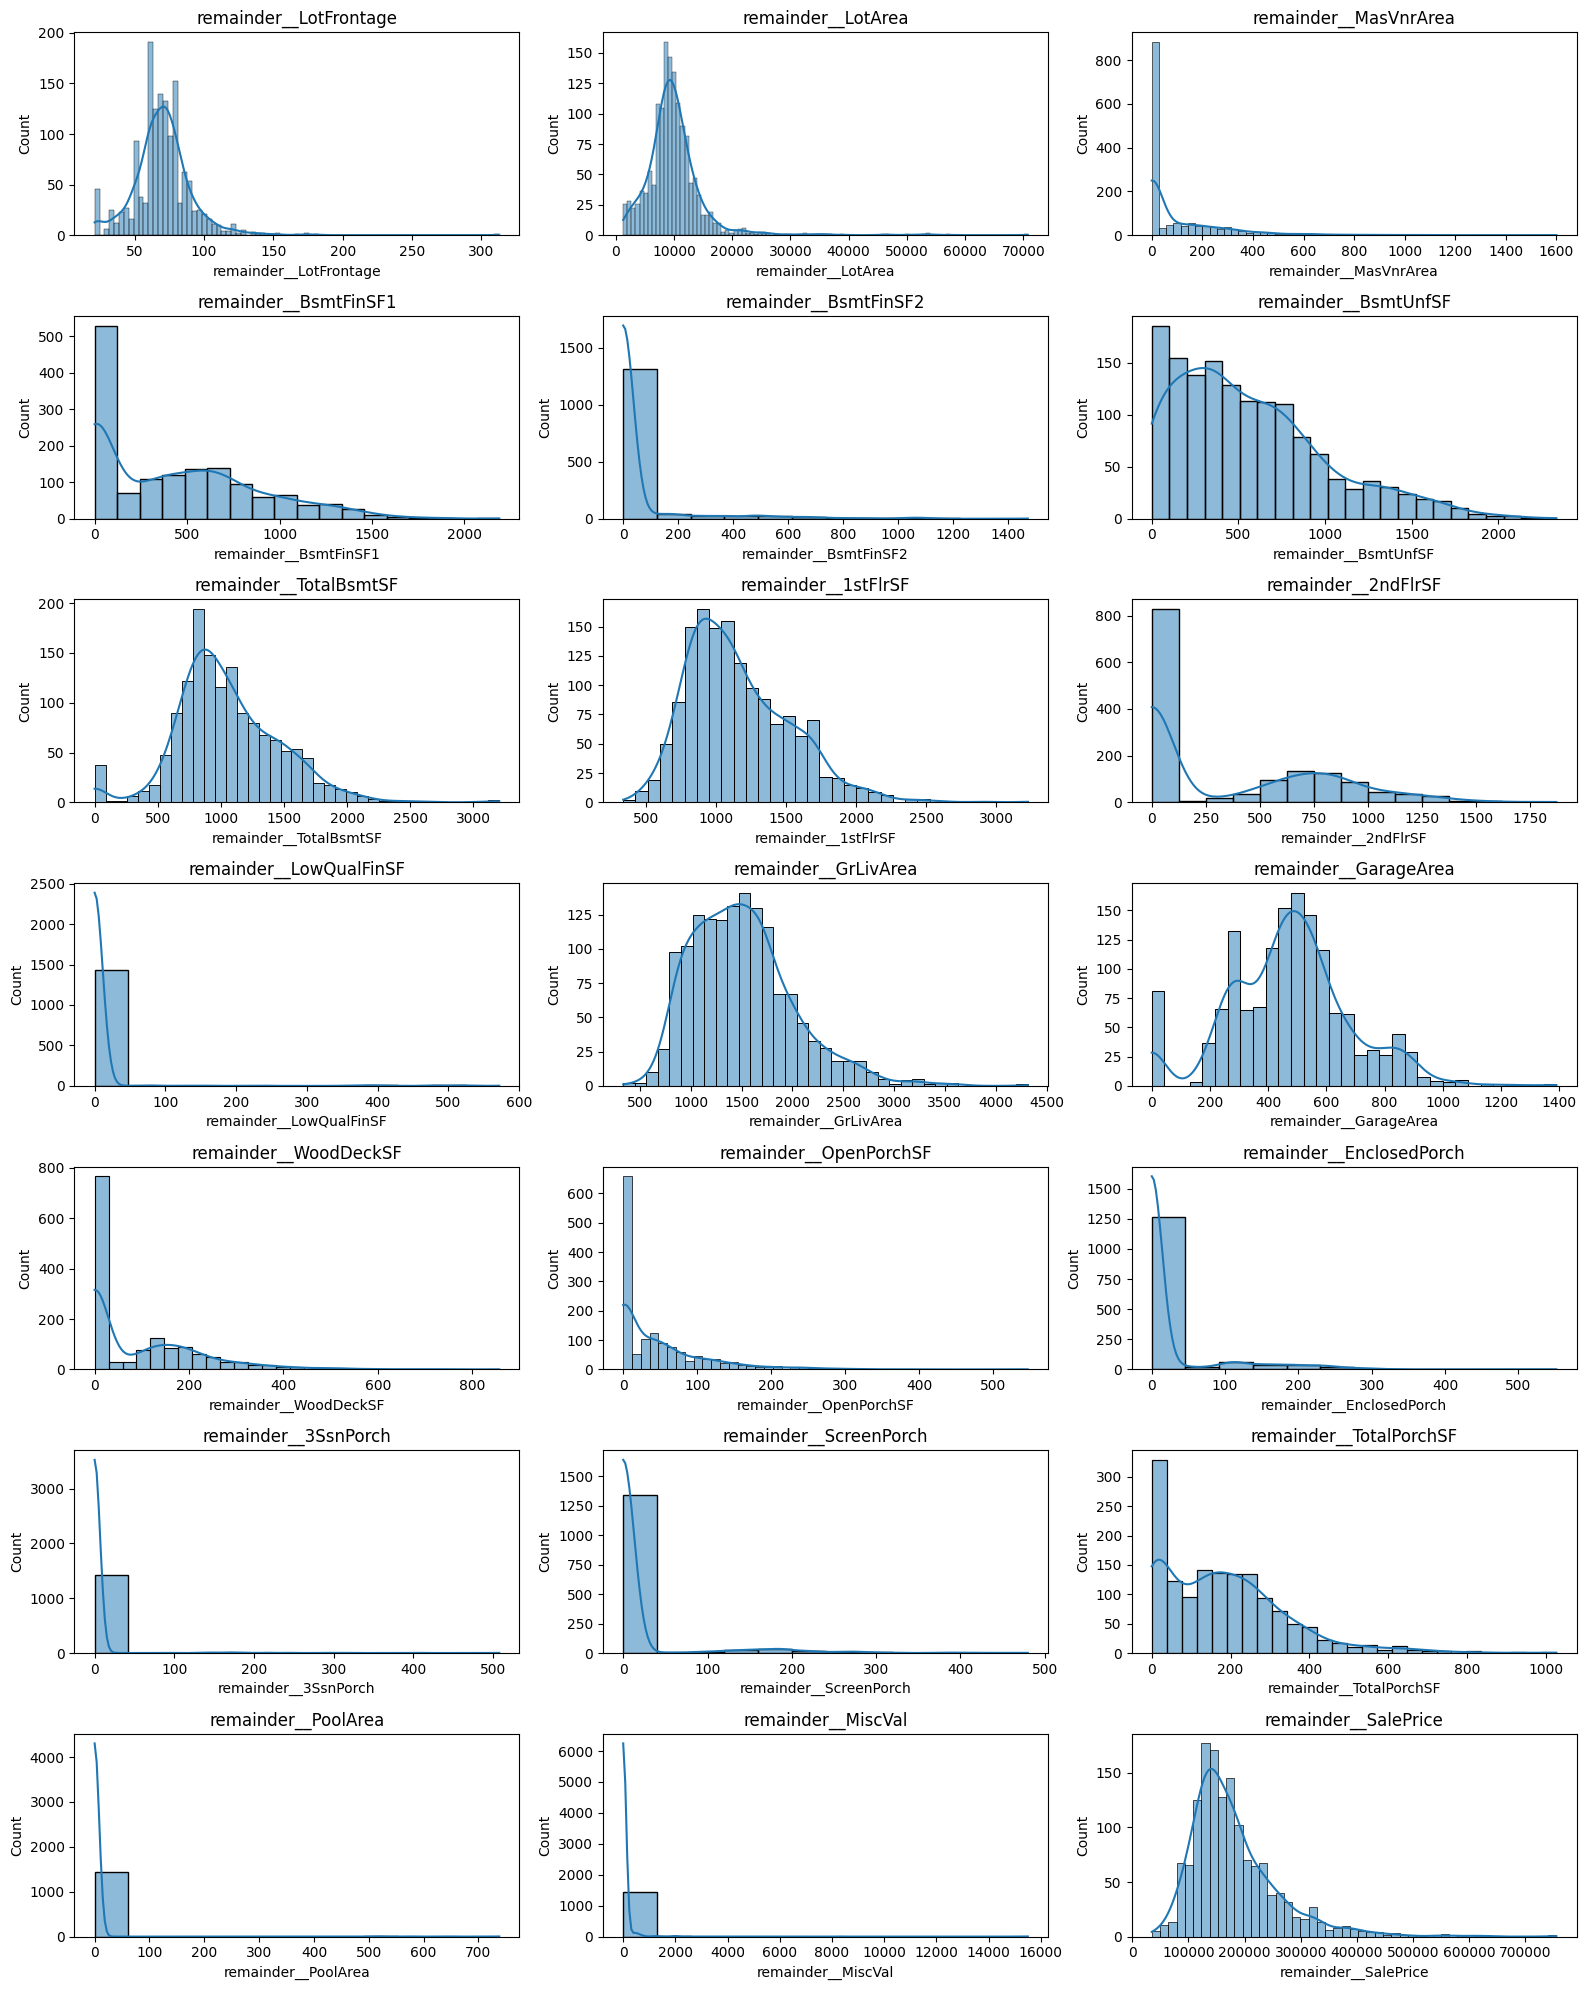

In [41]:
# Distribution of numerical columns
cont_num_cols = ['remainder__LotFrontage', 'remainder__LotArea', 'remainder__MasVnrArea', 'remainder__BsmtFinSF1', 
                 'remainder__BsmtFinSF2', 'remainder__BsmtUnfSF', 'remainder__TotalBsmtSF', 'remainder__1stFlrSF',
                 'remainder__2ndFlrSF', 'remainder__LowQualFinSF', 'remainder__GrLivArea', 'remainder__GarageArea',
                 'remainder__WoodDeckSF', 'remainder__OpenPorchSF', 'remainder__EnclosedPorch', 'remainder__3SsnPorch',
                 'remainder__ScreenPorch', 'remainder__TotalPorchSF', 'remainder__PoolArea', 'remainder__MiscVal', 'remainder__SalePrice']

fig, axes = plt.subplots(7, 3, figsize=(16, 20))
axes = axes.flatten()

for ax, col in zip(axes, cont_num_cols):
    sns.histplot(encoded_df_train[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Not all the variables need to be transformed, because features like porch and pool are mostly 0. It is enough to transform only few variables.

In [42]:
# Transform skewed variables
transform_df_train = encoded_df_train.copy()

trans_cols = ['remainder__LotFrontage', 'remainder__LotArea', 'remainder__MasVnrArea', 
                 'remainder__BsmtFinSF1', 'remainder__BsmtUnfSF', 'remainder__TotalBsmtSF', 
                 'remainder__1stFlrSF', 'remainder__2ndFlrSF', 'remainder__GrLivArea', 
                 'remainder__TotalPorchSF', 'remainder__GarageArea', 'remainder__SalePrice']

for col in trans_cols:
    transform_df_train[col] = pd.to_numeric(transform_df_train[col], errors='coerce')
    transform_df_train[col] = np.log1p(transform_df_train[col])

skew_metrics = transform_df_train[trans_cols].skew().sort_values()
print("Skewness metrics after log-transformations:")
print(skew_metrics)

Skewness metrics after log-transformations:
remainder__TotalBsmtSF    -5.169911
remainder__GarageArea     -3.476472
remainder__BsmtUnfSF      -2.183731
remainder__TotalPorchSF   -1.312238
remainder__LotFrontage    -1.024366
remainder__LotArea        -0.717679
remainder__BsmtFinSF1     -0.613320
remainder__GrLivArea      -0.088525
remainder__1stFlrSF        0.003474
remainder__SalePrice       0.096788
remainder__2ndFlrSF        0.294648
remainder__MasVnrArea      0.506460
dtype: float64


Choosing Yeo-Johnson transformation since log transformation is not helping much for some variables.

In [43]:
trans_cols = ['remainder__LotFrontage', 'remainder__BsmtUnfSF', 'remainder__TotalBsmtSF', 
              'remainder__TotalPorchSF', 'remainder__GarageArea']

pt = PowerTransformer(method='yeo-johnson')

transform_df_train[trans_cols] = pt.fit_transform(
    transform_df_train[trans_cols]
)

skew_metrics = (
    transform_df_train[trans_cols]
    .skew()
    .sort_values()
)

print(skew_metrics)

remainder__GarageArea     -1.145044
remainder__TotalPorchSF   -0.851469
remainder__BsmtUnfSF      -0.797573
remainder__TotalBsmtSF    -0.697229
remainder__LotFrontage     0.215080
dtype: float64


This works much better.

In [44]:
# Renaming columns for convenience
transformed_df_train = transform_df_train.rename(columns={
    'remainder__LotFrontage': 'remainder__yj_LotFrontage', 'remainder__LotArea':'remainder__log_LotArea', 
    'remainder__MasVnrArea':'remainder__log_MasVnrArea', 'remainder__BsmtFinSF1':'remainder__log_BsmtFinSF1', 
    'remainder__BsmtUnfSF':'remainder__yj_BsmtUnfSF', 'remainder__TotalBsmtSF':'remainder__yj_TotalBsmtSF', 
    'remainder__1stFlrSF':'remainder__log_1stFlrSF', 'remainder__2ndFlrSF':'remainder__log_2ndFlrSF', 
    'remainder__GrLivArea':'remainder__log_GrLivArea', 'remainder__GarageArea':'remainder__yj_GarageArea',
    'remainder__SalePrice':'remainder__log_SalePrice', 'remainder__TotalPorchSF':'remainder__yj_TotalPorchSF'
})

transformed_df_train.head()

,nominal__MSSubClass_MSSC160,nominal__MSSubClass_MSSC180,nominal__MSSubClass_MSSC190,nominal__MSSubClass_MSSC20,nominal__MSSubClass_MSSC30,nominal__MSSubClass_MSSC40,nominal__MSSubClass_MSSC45,nominal__MSSubClass_MSSC50,nominal__MSSubClass_MSSC60,nominal__MSSubClass_MSSC70,nominal__MSSubClass_MSSC75,nominal__MSSubClass_MSSC80,nominal__MSSubClass_MSSC85,nominal__MSSubClass_MSSC90,nominal__MSZoning_FV,nominal__MSZoning_RH,nominal__MSZoning_RL,nominal__MSZoning_RM,nominal__Street_Pave,nominal__Alley_No alley access,nominal__Alley_Pave,nominal__LotShape_IR2,nominal__LotShape_IR3,nominal__LotShape_Reg,nominal__LandContour_HLS,nominal__LandContour_Low,nominal__LandContour_Lvl,nominal__Utilities_NoSeWa,nominal__LotConfig_CulDSac,nominal__LotConfig_FR2,nominal__LotConfig_FR3,nominal__LotConfig_Inside,nominal__LandSlope_Mod,nominal__LandSlope_Sev,nominal__Neighborhood_Blueste,nominal__Neighborhood_BrDale,nominal__Neighborhood_BrkSide,nominal__Neighborhood_ClearCr,nominal__Neighborhood_CollgCr,nominal__Neighborhood_Crawfor,nominal__Neighborhood_Edwards,nominal__Neighborhood_Gilbert,nominal__Neighborhood_IDOTRR,nominal__Neighborhood_MeadowV,nominal__Neighborhood_Mitchel,nominal__Neighborhood_NAmes,nominal__Neighborhood_NPkVill,nominal__Neighborhood_NWAmes,nominal__Neighborhood_NoRidge,nominal__Neighborhood_NridgHt,nominal__Neighborhood_OldTown,nominal__Neighborhood_SWISU,nominal__Neighborhood_Sawyer,nominal__Neighborhood_SawyerW,nominal__Neighborhood_Somerst,nominal__Neighborhood_StoneBr,nominal__Neighborhood_Timber,nominal__Neighborhood_Veenker,nominal__Condition1_Feedr,nominal__Condition1_Norm,nominal__Condition1_PosA,nominal__Condition1_PosN,nominal__Condition1_RRAe,nominal__Condition1_RRAn,nominal__Condition1_RRNe,nominal__Condition1_RRNn,nominal__Condition2_Feedr,nominal__Condition2_Norm,nominal__Condition2_PosA,nominal__Condition2_PosN,nominal__Condition2_RRAe,nominal__Condition2_RRAn,nominal__Condition2_RRNn,nominal__BldgType_2fmCon,nominal__BldgType_Duplex,nominal__BldgType_Twnhs,nominal__BldgType_TwnhsE,nominal__HouseStyle_1.5Unf,nominal__HouseStyle_1Story,nominal__HouseStyle_2.5Fin,nominal__HouseStyle_2.5Unf,nominal__HouseStyle_2Story,nominal__HouseStyle_SFoyer,nominal__HouseStyle_SLvl,nominal__HouseRemod_Y,nominal__RoofStyle_Gable,nominal__RoofStyle_Gambrel,nominal__RoofStyle_Hip,nominal__RoofStyle_Mansard,nominal__RoofStyle_Shed,nominal__RoofMatl_Membran,nominal__RoofMatl_Metal,nominal__RoofMatl_Roll,nominal__RoofMatl_Tar&Grv,nominal__RoofMatl_WdShake,nominal__RoofMatl_WdShngl,nominal__Exterior1st_AsphShn,nominal__Exterior1st_BrkComm,nominal__Exterior1st_BrkFace,nominal__Exterior1st_CBlock,nominal__Exterior1st_CemntBd,nominal__Exterior1st_HdBoard,nominal__Exterior1st_ImStucc,nominal__Exterior1st_MetalSd,nominal__Exterior1st_Plywood,nominal__Exterior1st_Stone,nominal__Exterior1st_Stucco,nominal__Exterior1st_VinylSd,nominal__Exterior1st_Wd Sdng,nominal__Exterior1st_WdShing,nominal__Exterior2nd_AsphShn,nominal__Exterior2nd_Brk Cmn,nominal__Exterior2nd_BrkFace,nominal__Exterior2nd_CBlock,nominal__Exterior2nd_CmentBd,nominal__Exterior2nd_HdBoard,nominal__Exterior2nd_ImStucc,nominal__Exterior2nd_MetalSd,nominal__Exterior2nd_Other,nominal__Exterior2nd_Plywood,nominal__Exterior2nd_Stone,nominal__Exterior2nd_Stucco,nominal__Exterior2nd_VinylSd,nominal__Exterior2nd_Wd Sdng,nominal__Exterior2nd_Wd Shng,nominal__MasVnrType_BrkFace,nominal__MasVnrType_None,nominal__MasVnrType_Stone,nominal__Foundation_CBlock,nominal__Foundation_PConc,nominal__Foundation_Slab,nominal__Foundation_Stone,nominal__Foundation_Wood,nominal__LowQualFin_Y,nominal__Heating_GasA,nominal__Heating_GasW,nominal__Heating_Grav,nominal__Heating_OthW,nominal__Heating_Wall,nominal__CentralAir_Y,nominal__Electrical_FuseF,nominal__Electrical_FuseP,nominal__Electrical_Mix,nominal__Electrical_SBrkr,nominal__GarageType_Attchd,nominal__GarageType_Basment,nominal__GarageType_BuiltIn,nominal__GarageType_CarPort,nominal__GarageType_Detchd,nominal__GarageType_No garage,nominal__Paved